# Is the $\vartheta$ prior median sensitive to random parameter perturbations?

Check figure for the prior calibration in `theta_prior.ipynb`.

**Baseline.** Draw `N_SAMPLES` samples from each parameter prior and push them through
`get_angle_r2` / `get_angle_r3` to get the implied prior on $\vartheta$.

**Perturbation.** Repeat `N_PERTURB` times, each time jittering the parameters by
`old + n * std` with $n \sim \mathcal{N}(0, 1)$, and recompute the $\vartheta$ prior.
Two flavours of "perturb the parameters" are run, because they answer different questions:

1. **Jitter draws** -- an independent $n$ for *every parameter of every sample*. This is
   the literal `old + n * std` applied to the sample cloud; it inflates each parameter's
   spread by $\sqrt{2}$ and asks whether the median survives extra sampling noise.
2. **Shift centres** -- one $n$ per parameter, shared across all samples, applied to the
   prior central value. The prior keeps its width but sits somewhere else in parameter
   space. This is the harsher test: it asks how much the median moves if we had picked
   central values one standard deviation away.

The diagnostic is the spread of the `N_PERTURB` perturbed medians around the baseline median.

In [1]:
import argparse

import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import gaussian_kde

from var_assim.plotting.presets import get_presets
from var_assim.plotting.utils import make_figure_filename
from var_assim.plotting.pproc import get_angle_r2, get_angle_r3
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.config import NOISE_PATH, PRIOR_PATH, FIGS_DIR

presets, _ = get_presets()
plt.rcParams.update(presets)

%load_ext autoreload
%autoreload 2

SAVE_FIGS = True

In [2]:
# high level parameters
N_SAMPLES = 1000  # parameter draws per prior
N_PERTURB = 1000  # perturbation realizations
SEED = 42

PHI = 0.09  # forcing efficacy of SAI (get_angle_r{2,3} default)

# Harding et al. (2023) reported values, for reference
HARDING_MEDIAN_REPORTED = 15

rng = np.random.default_rng(SEED)

## Priors

Same dataclass path as `theta_prior.ipynb`, so the central values and standard deviations
are exactly the ones in `config/priors.yaml`.

In [3]:
def make_prior(model):
    """Build a ClimateModelPriors object for a given model key."""

    cli = argparse.Namespace(
        model=model,
        ssp='ssp245',
        noise_model='AR1',
        tmin=2023,
        theta=14,
        AR=1,
        ecs=3.0,
        DEGpDEC=0.1,
        NYRSRAMP=50,
        Nens=1000,
        reg_noise=False,
        windowing='ws_gradual'
    )

    Noise = ClimateModelNoise.from_cli_and_yaml(cli, NOISE_PATH)
    return ClimateModelPriors.from_cli_and_yaml_and_noise(cli, PRIOR_PATH, Noise)


Prior_r2 = make_prior('pco2geowc')
Prior_r3 = make_prior('pco2geowc3')

In [4]:
def get_cen_std(Prior, N_regs):
    """Stack the prior central values and stds in get_angle argument order.

    Order is [alpha_1..alpha_N, beta_1..beta_N, lambda, epsilon, gamma].
    """

    cen = np.array([*Prior.ALPHA_CEN[:N_regs], *Prior.BETA_CEN[:N_regs],
                    Prior.L_CEN, Prior.EPS_CEN, Prior.G_CEN])
    std = np.array([*Prior.ALPHA_STD[:N_regs], *Prior.BETA_STD[:N_regs],
                    Prior.L_STD, Prior.EPS_STD, Prior.G_STD])
    return cen, std


CEN_R2, STD_R2 = get_cen_std(Prior_r2, 2)
CEN_R3, STD_R3 = get_cen_std(Prior_r3, 3)

PARAM_NAMES_R2 = ['alpha_1', 'alpha_2', 'beta_1', 'beta_2', 'lambda', 'epsilon', 'gamma']
PARAM_NAMES_R3 = ['alpha_1', 'alpha_2', 'alpha_3', 'beta_1', 'beta_2', 'beta_3',
                  'lambda', 'epsilon', 'gamma']

for name, cen, std in zip(PARAM_NAMES_R2, CEN_R2, STD_R2):
    print(f"r2 {name:>8}: cen={cen: .6f}, std={std: .6f}")
print()
for name, cen, std in zip(PARAM_NAMES_R3, CEN_R3, STD_R3):
    print(f"r3 {name:>8}: cen={cen: .6f}, std={std: .6f}")

r2  alpha_1: cen= 1.600000, std= 0.281600
r2  alpha_2: cen= 1.300000, std= 0.228800
r2   beta_1: cen=-0.018121, std= 0.010648
r2   beta_2: cen= 0.018121, std= 0.010648
r2   lambda: cen= 1.058205, std= 0.317461
r2  epsilon: cen= 1.580000, std= 0.128000
r2    gamma: cen= 0.700000, std= 0.210000

r3  alpha_1: cen= 1.600000, std= 0.320000
r3  alpha_2: cen= 1.300000, std= 0.260000
r3  alpha_3: cen= 1.275000, std= 0.255000
r3   beta_1: cen=-0.018414, std= 0.014300
r3   beta_2: cen= 0.018414, std= 0.014300
r3   beta_3: cen=-0.010230, std= 0.014300
r3   lambda: cen= 1.058205, std= 0.317461
r3  epsilon: cen= 1.580000, std= 0.128000
r3    gamma: cen= 0.700000, std= 0.210000


## Baseline prior on $\vartheta$

`N_SAMPLES` draws from each parameter prior, pushed through `get_angle_r2` / `get_angle_r3`.

In [5]:
# standard normal draws that define the baseline parameter samples; reused below so that
# the centre-shift experiment changes *only* the centres
Z_R2 = rng.standard_normal((len(CEN_R2), N_SAMPLES))
Z_R3 = rng.standard_normal((len(CEN_R3), N_SAMPLES))

params_r2 = CEN_R2[:, None] + STD_R2[:, None] * Z_R2
params_r3 = CEN_R3[:, None] + STD_R3[:, None] * Z_R3

In [6]:
theta_r2 = np.array([get_angle_r2(a1, a2, b1, b2, l, e, g)
                     for a1, a2, b1, b2, l, e, g in zip(*params_r2)]).ravel()

theta_r3 = np.array([get_angle_r3(a1, a2, a3, b1, b2, b3, l, e, g)
                     for a1, a2, a3, b1, b2, b3, l, e, g in zip(*params_r3)]).ravel()

print(f"Two region  : median={np.median(theta_r2):.3f}, "
      f"5th={np.percentile(theta_r2, 5):.3f}, 95th={np.percentile(theta_r2, 95):.3f}")
print(f"Three region: median={np.median(theta_r3):.3f}, "
      f"5th={np.percentile(theta_r3, 5):.3f}, 95th={np.percentile(theta_r3, 95):.3f}")

Two region  : median=15.357, 5th=4.551, 95th=30.835
Three region: median=14.970, 5th=5.262, 95th=30.344


## Vectorized angle

`get_angle_r{2,3}` take scalars, so `N_PERTURB * N_SAMPLES` calls in a python loop is slow.
Below is the same algebra written for arrays; the assertion checks it reproduces the library
functions to machine precision on the baseline draws, and it is what the perturbation loop uses.

In [7]:
def get_angle_vec(params, N_regs, phi=PHI):
    """Vectorized version of get_angle_r{2,3}.

    Parameters
    ----------
    params: (2 * N_regs + 3, N) array
        [alpha_1..alpha_N, beta_1..beta_N, lambda, epsilon, gamma]

    N_regs: int
        number of regions

    phi: float
        forcing efficacy of SAI

    Returns
    -------
    angle: (N,) array
        the inequality angle parameter for SAI, in degrees
    """

    alphas = params[:N_regs]
    betas = params[N_regs:2 * N_regs]
    l, e, g = params[2 * N_regs:]

    inside = (l + e * g) / phi
    r = -(betas * inside - alphas)

    num = np.sum(alphas * r, axis=0)
    denom = np.sqrt(np.sum(alphas**2, axis=0) * np.sum(r**2, axis=0))
    return np.arccos(num / denom) * 180 / np.pi


assert np.allclose(get_angle_vec(params_r2, 2), theta_r2, atol=1e-9)
assert np.allclose(get_angle_vec(params_r3, 3), theta_r3, atol=1e-9)
print("vectorized angle matches get_angle_r2 / get_angle_r3")

vectorized angle matches get_angle_r2 / get_angle_r3


## Perturbation experiment

In [8]:
def perturb_medians(cen, std, Z, N_regs, mode, n_perturb=N_PERTURB, rng=rng):
    """Recompute the theta prior n_perturb times under random parameter perturbations.

    Parameters
    ----------
    cen, std: (n_par,) arrays
        prior central values and standard deviations

    Z: (n_par, N_SAMPLES) array
        standard normal draws defining the baseline parameter samples

    N_regs: int
        number of regions

    mode: str
        'jitter' -> old + n * std with an independent n per parameter *per sample*
        'shift'  -> the prior centre moves by n * std, one n per parameter

    Returns
    -------
    medians: (n_perturb,) array
        median of the theta prior for each perturbation realization

    first_sample: (N_SAMPLES,) array
        the full theta sample from the first realization, for plotting

    samples: (n_perturb, N_SAMPLES) array
        every perturbed theta sample
    """

    n_par = len(cen)
    baseline = cen[:, None] + std[:, None] * Z
    samples = np.empty((n_perturb, Z.shape[1]))

    for k in range(n_perturb):
        if mode == 'jitter':
            n = rng.standard_normal((n_par, Z.shape[1]))
            params = baseline + std[:, None] * n
        elif mode == 'shift':
            n = rng.standard_normal((n_par, 1))
            params = (cen[:, None] + std[:, None] * n) + std[:, None] * Z
        else:
            raise ValueError(f"unknown mode: {mode}")

        samples[k] = get_angle_vec(params, N_regs)

    return np.median(samples, axis=1), samples[0], samples


results = {}
for label, cen, std, Z, N_regs in [('two region', CEN_R2, STD_R2, Z_R2, 2),
                                   ('three region', CEN_R3, STD_R3, Z_R3, 3)]:
    for mode in ['jitter', 'shift']:
        medians, first, samples = perturb_medians(cen, std, Z, N_regs, mode)
        results[(label, mode)] = {'medians': medians, 'first': first, 'samples': samples}
        print(f"{label:>12} / {mode:>6}: done")

  two region / jitter: done
  two region /  shift: done
three region / jitter: done
three region /  shift: done


In [9]:
BASELINE = {'two region': theta_r2, 'three region': theta_r3}

print(f"{'model':>12} {'mode':>7} {'baseline':>9} {'med(med)':>9} {'std(med)':>9} "
      f"{'5th':>7} {'95th':>7} {'max shift':>10}")
for (label, mode), res in results.items():
    base = np.median(BASELINE[label])
    m = res['medians']
    print(f"{label:>12} {mode:>7} {base:9.3f} {np.median(m):9.3f} {np.std(m):9.3f} "
          f"{np.percentile(m, 5):7.3f} {np.percentile(m, 95):7.3f} "
          f"{np.abs(m - base).max():10.3f}")

       model    mode  baseline  med(med)  std(med)     5th    95th  max shift
  two region  jitter    15.357    14.629     0.359  14.043  15.219      2.120
  two region   shift    15.357    14.738     7.597   5.618  29.961     43.753
three region  jitter    14.970    16.218     0.337  15.668  16.770      2.625
three region   shift    14.970    15.840     6.973   7.689  29.949     33.469


## Figure

Left column: the baseline $\vartheta$ prior against a subsample of the perturbed priors
(thin lines, one per realization). Right column: the distribution of the `N_PERTURB`
perturbed medians, against the baseline median.

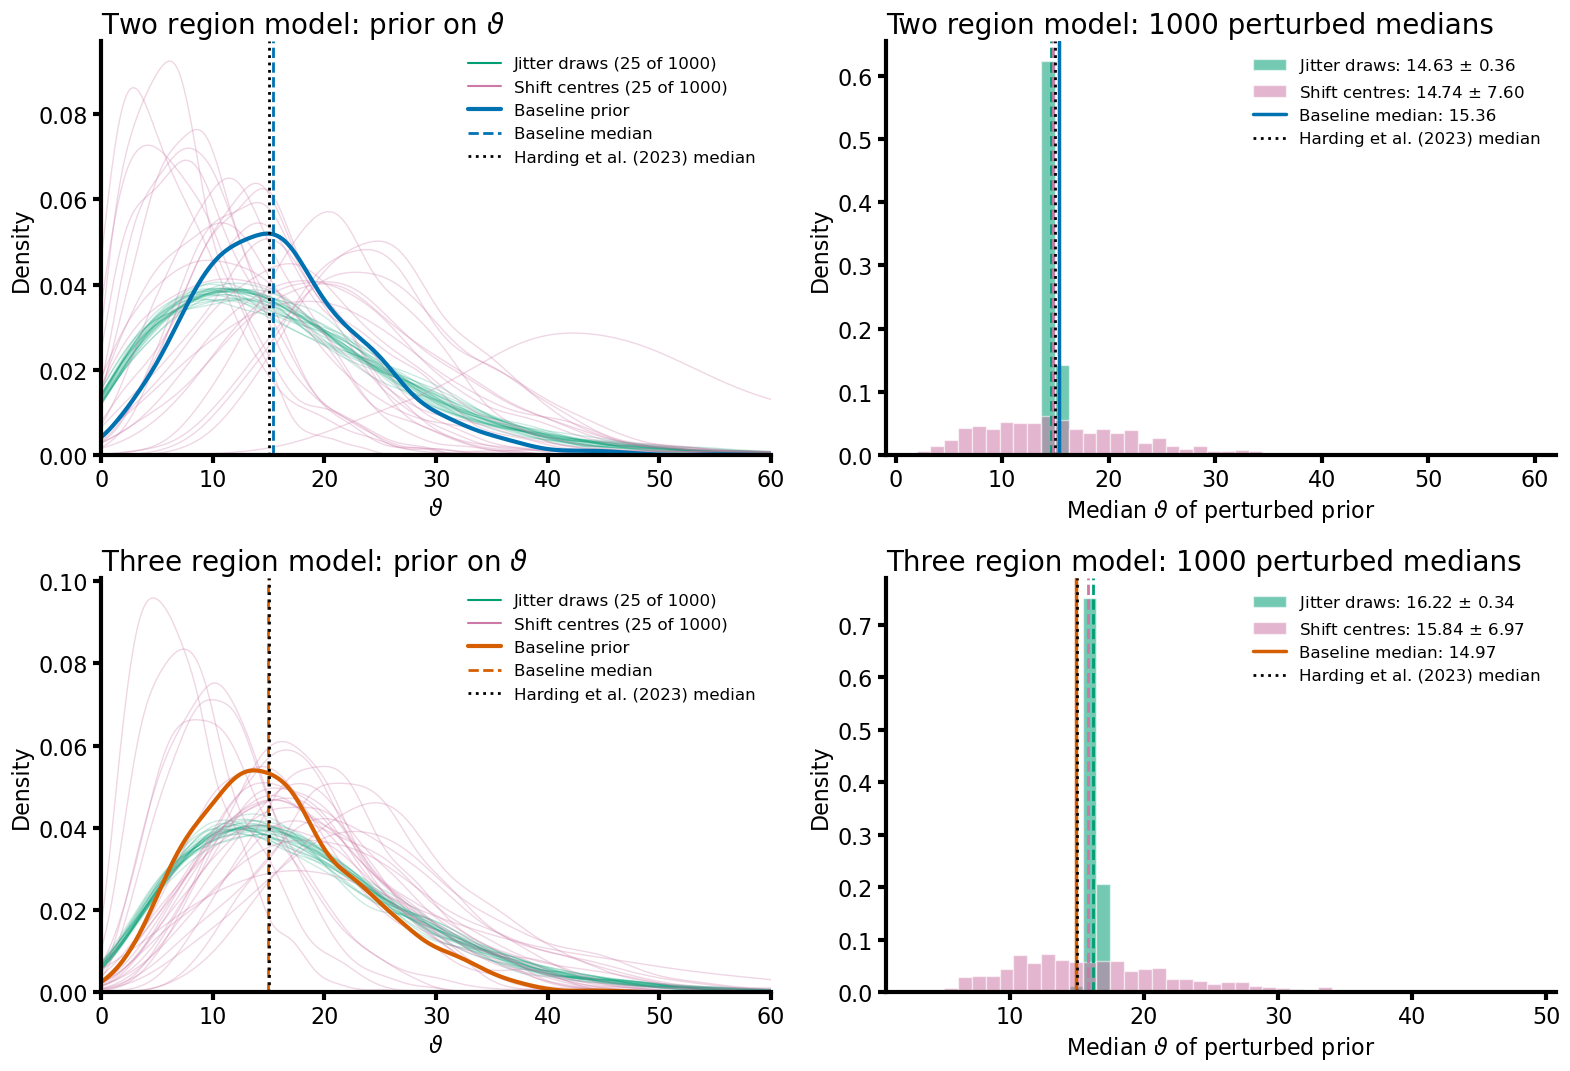

In [10]:
MODE_COLORS = {'jitter': '#009E73', 'shift': '#CC79A7'}
MODE_ALPHAS = {'jitter': 0.2, 'shift': 0.3}
MODE_LABELS = {'jitter': 'Jitter draws', 'shift': 'Shift centres'}
MODEL_COLORS = {'two region': '#0072B2', 'three region': '#D55E00'}
N_SHOW = 25  # perturbed priors drawn per mode in the left column

fig, axs = plt.subplots(2, 2, figsize=(16, 11))

xlims = (0, 60)
xvals = np.linspace(*xlims, 500)

for row, label in enumerate(['two region', 'three region']):
    base = BASELINE[label]
    base_med = np.median(base)

    # --- left: prior densities ---
    ax = axs[row, 0]
    for mode in ['jitter', 'shift']:
        for k in range(N_SHOW):
            ax.plot(xvals, gaussian_kde(results[(label, mode)]['samples'][k])(xvals),
                    color=MODE_COLORS[mode], alpha=MODE_ALPHAS[mode], linewidth=1,
                    linestyle='solid')
        ax.plot([], [], color=MODE_COLORS[mode], linewidth=1.5, linestyle='solid',
                label=f"{MODE_LABELS[mode]} ({N_SHOW} of {N_PERTURB})")

    ax.plot(xvals, gaussian_kde(base)(xvals), color=MODEL_COLORS[label],
            linewidth=3, linestyle='solid', label='Baseline prior')
    ax.axvline(base_med, color=MODEL_COLORS[label], linestyle='dashed', linewidth=2,
               label='Baseline median')
    ax.axvline(HARDING_MEDIAN_REPORTED, color='black', linestyle='dotted', linewidth=2,
               label='Harding et al. (2023) median')

    ax.set_xlim(xlims)
    ax.set_ylim((0, None))
    ax.set_xlabel(r'$\vartheta$')
    ax.set_ylabel('Density')
    ax.set_title(f"{label.capitalize()} model: prior on " + r"$\vartheta$")
    ax.legend(fontsize=12)

    # --- right: distribution of perturbed medians ---
    ax = axs[row, 1]
    all_med = np.concatenate([results[(label, m)]['medians'] for m in ['jitter', 'shift']])
    bins = np.linspace(min(all_med.min(), base_med), max(all_med.max(), base_med), 45)

    for mode in ['jitter', 'shift']:
        m = results[(label, mode)]['medians']
        ax.hist(m, bins=bins, color=MODE_COLORS[mode], alpha=0.55, density=True,
                label=(f"{MODE_LABELS[mode]}: "
                       rf"{np.median(m):.2f} $\pm$ {np.std(m):.2f}"))
        ax.axvline(np.median(m), color=MODE_COLORS[mode], linestyle='dashed', linewidth=2)

    ax.axvline(base_med, color=MODEL_COLORS[label], linestyle='solid', linewidth=2.5,
               label=f'Baseline median: {base_med:.2f}')
    ax.axvline(HARDING_MEDIAN_REPORTED, color='black', linestyle='dotted', linewidth=2,
               label='Harding et al. (2023) median')

    ax.set_xlabel(r'Median $\vartheta$ of perturbed prior')
    ax.set_ylabel('Density')
    ax.set_title(f"{label.capitalize()} model: {N_PERTURB} perturbed medians")
    ax.legend(fontsize=12)

plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(make_figure_filename('theta_prior_perturbation_check', FIGS_DIR / 'cal'),
                bbox_inches='tight')

plt.show()

## Per-parameter sensitivity

The centre-shift result above mixes all parameters together. Shifting one parameter's centre
at a time by $\pm 1$ std says which parameter the median actually responds to.

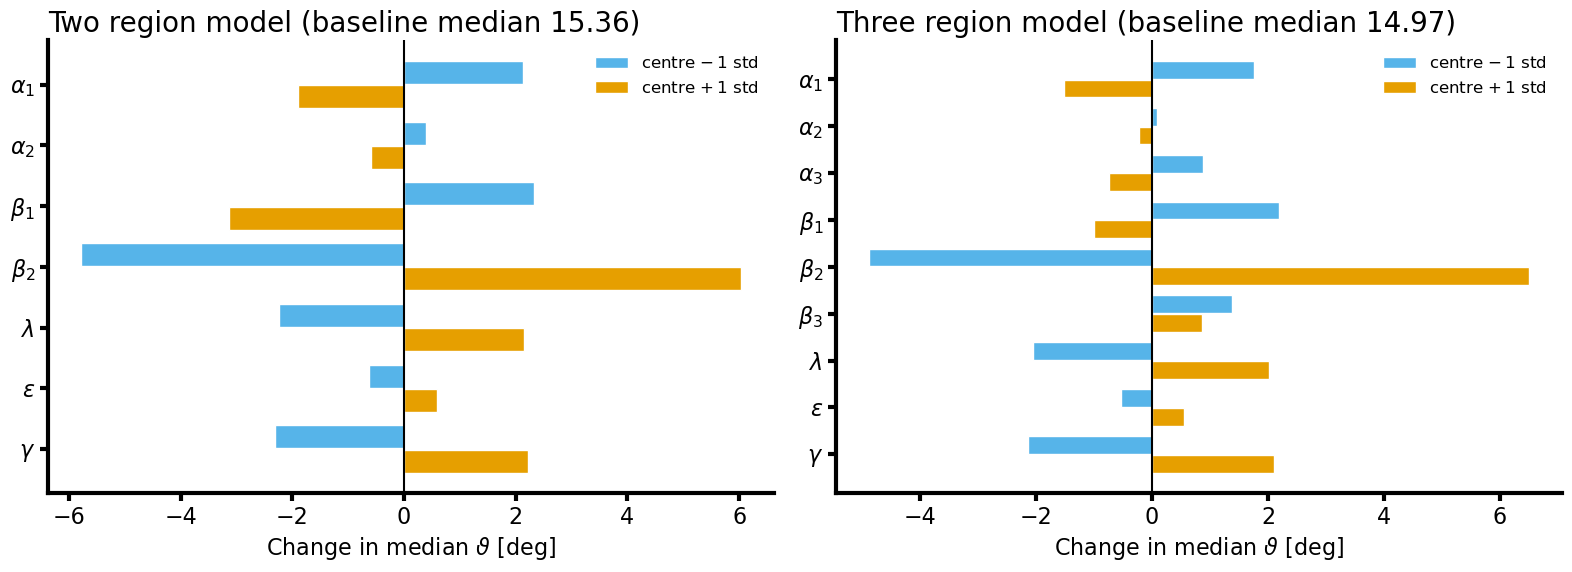

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, cen, std, Z, N_regs, names in [
    (axs[0], 'two region', CEN_R2, STD_R2, Z_R2, 2, PARAM_NAMES_R2),
    (axs[1], 'three region', CEN_R3, STD_R3, Z_R3, 3, PARAM_NAMES_R3),
]:
    base_med = np.median(BASELINE[label])
    lo, hi = [], []

    for i in range(len(cen)):
        for sign, store in [(-1, lo), (+1, hi)]:
            shifted = cen.copy()
            shifted[i] += sign * std[i]
            params = shifted[:, None] + std[:, None] * Z
            store.append(np.median(get_angle_vec(params, N_regs)) - base_med)

    y = np.arange(len(cen))
    ax.barh(y - 0.2, lo, height=0.38, color='#56B4E9', label=r'centre $-\,1$ std')
    ax.barh(y + 0.2, hi, height=0.38, color='#E69F00', label=r'centre $+\,1$ std')
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_yticks(y)
    ax.set_yticklabels([rf'$\{n}$' if '_' not in n else
                        rf'$\{n.split("_")[0]}_{n.split("_")[1]}$' for n in names])
    ax.invert_yaxis()
    ax.set_xlabel(r'Change in median $\vartheta$ [deg]')
    ax.set_title(f"{label.capitalize()} model (baseline median {base_med:.2f})")
    ax.legend(fontsize=12)

plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(make_figure_filename('theta_prior_median_param_sensitivity', FIGS_DIR / 'cal'),
                bbox_inches='tight')

plt.show()

## Takeaway

Numbers below are from the `SEED = 42` run; rerun to confirm they are stable.

* **Jitter draws** (extra per-sample noise): the median barely moves. Its realization-to-realization
  spread is $\pm 0.35^\circ$ in both models, but note the *systematic* offset -- $-0.7^\circ$
  (two region) and $+1.2^\circ$ (three region) -- which is larger than the spread. That offset is
  not noise: adding `n * std` on top of the draws inflates every parameter's prior width by
  $\sqrt{2}$, and because $\vartheta$ is a nonlinear function of the parameters, a wider
  parameter prior maps to a differently-centred $\vartheta$ prior. So the median is robust to
  *sampling* noise but not perfectly invariant to prior width.
* **Shift centres** (the whole prior moves by $1$ std in every parameter): the median is highly
  sensitive. The perturbed medians span roughly $6$--$30^\circ$ (std $\approx 7^\circ$ in both
  models), i.e. the full width of the baseline prior itself. The calibration of the median to
  Harding et al. (2023) therefore rests on the parameter central values, not on the sample draws.
* The per-parameter sweep shows the sensitivity is dominated by $\beta_2$ (roughly
  $\pm 6^\circ$ per std), with $\beta_1$, $\lambda$, $\gamma$ and $\alpha_1$ each worth
  about $2^\circ$ and $\alpha_2$, $\alpha_3$, $\epsilon$ negligible. Note the response to
  $\beta_2$ is asymmetric, again reflecting the nonlinearity of the angle.